<p align="center">
  <img src="https://raw.githubusercontent.com/OlaTarig/Qiskit-Fall-Fest/515a84871fdf3a42350026dfdc7dc712ad52979e/Black%20and%20Yellow%20Modern%20Cyber%20Monday%20Banner.png"
       alt="Qiskit Fall Fest Banner"
       width="100%">
</p>


# Quantum Machine Learning Basics

###### By QFF KSU 2025 Organizing Team

## **0.0 Recap**

### **0.1 Importing**

In [ ]:
#Install the required libraries
!pip install qiskit qiskit-aer  #install qiskit and qiskit-aer
!pip install -U qiskit-machine-learning #install qiskit-machine-learning
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: qiskit
    Found existing installation: qiskit 2.2.3
    Uninstalling qiskit-2.2.3:
      Successfully uninstalled qis

In [ ]:
#Importing the libraries to check if you are using the right version, and using it later in the practical section in the notebook.
import sys
import qiskit
import matplotlib
import qiskit_machine_learning
import qiskit_aer
print("Python version:", sys.version) #printing the python version
print("Qiskit version:", qiskit.__version__) #printing the qiskit version
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__) #printing qiskit machine learning version
print("Qiskit Aer version:", qiskit_aer.__version__) #printing aer version

In [ ]:
#Import the necessary libraries

#  Core Python and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

#  Classical machine learning (scikit-learn)
from sklearn.datasets import make_classification         # generate dataset
from sklearn.preprocessing import MinMaxScaler           # normalize data
from sklearn.model_selection import train_test_split     # split into train/test sets

# Qiskit modules (circuits, simulators, visualization)
from qiskit import QuantumCircuit, transpile             # basic quantum circuit creation and transpilation
from qiskit_aer import AerSimulator                      # simulator backend
from qiskit.visualization import plot_bloch_multivector, plot_histogram  # visualization helpers

#  Qiskit circuit libraries (feature maps and ansatzes)
from qiskit.circuit.library import (
    PauliFeatureMap,                                     # general Pauli-based data encoding map
    ZZFeatureMap,                                        # entangling Z feature map (for kernels)
    RealAmplitudes                                       # variational ansatz (trainable part of QNN/VQC)
)
from qiskit.circuit import Parameter                     # symbolic parameters for circuits

# Qiskit Machine Learning components
from qiskit_machine_learning.utils import algorithm_globals           # reproducibility tools
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B        # classical optimizers
from qiskit_machine_learning.circuit.library import QNNCircuit         # prebuilt QNN layer
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN  # QNN backends
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC  # classifiers
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR    # regressors

# Reproducibility setup
algorithm_globals.random_seed = 42


### **0.2 Recap of Quantum Gates & Measurements**


#### **0.2.1 Basic Quantum Gates**


###### **0.2.1.1 X(NOT) Gate**


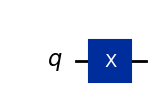

In [ ]:
#Implement X gate
qc = QuantumCircuit(1)
qc.x(0)
qc.draw('mpl')

###### **0.2.1.2 Hadamard Gate**


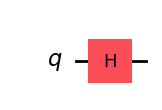

In [ ]:
#Implement Hadamard gate
qc = QuantumCircuit(1)
qc.h(0)
qc.draw('mpl')

###### **0.2.1.3 Rotation Gates**


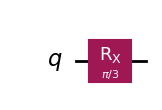

In [ ]:
#Implementing RX gate
from math import pi
qc = QuantumCircuit(1)
qc.rx(pi/3,0)
qc.draw('mpl')

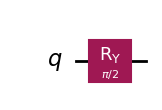

In [ ]:
#Implementing RY gate
qc = QuantumCircuit(1)
qc.ry(pi/2,0)
qc.draw('mpl')

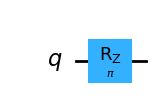

In [ ]:
#Implementing RZ gate
qc = QuantumCircuit(1)
qc.rz(pi,0)
qc.draw('mpl')

###### **0.2.1.4 CNOT Gate**


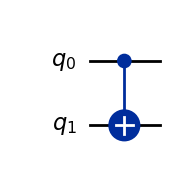

In [ ]:
#Implement CNOT gate
qc = QuantumCircuit(2)
qc.cx(0,1)
qc.draw('mpl')

#### **0.2.2 Measurements**

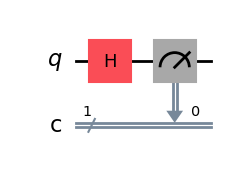

In [ ]:
#Implement Hadamard Gate and measures it
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
qc.draw('mpl')

{'0': 484, '1': 516}


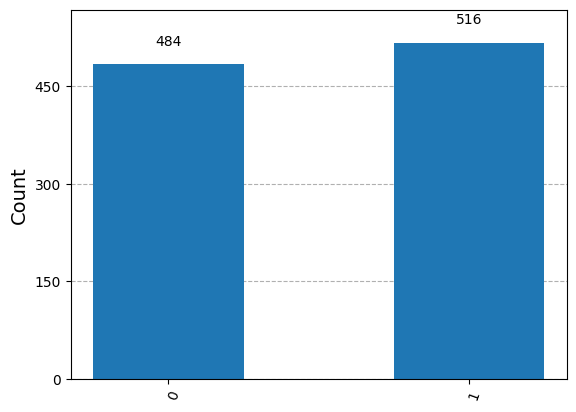

In [ ]:
simulator = AerSimulator()
transpiled_circuit = transpile(qc, simulator)
result = simulator.run(transpiled_circuit,shots=1000).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

## **1.0 What's Quantum Machine Learning (QML)?**

<a href="https://imgflip.com/i/aa8njo"><img src="https://i.imgflip.com/aa8njo.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>


The term Quantum Machine Learning (QML) combines two fields : quantum computing and machine learning:

* **Quantum computing** is the study of information processing using devices that follow the laws of quantum mechanics.

* **Machine learning (ML)**, on the other hand, is the art and science of designing algorithms that learn from data to solve problems, rather than being explicitly programmed with rules. It enables computers to recognize patterns, make predictions, and improve performance through experience.

## **So, what would we get from merging these two powerful fields together?**

### **Four approaches**
Quantum Machine Learning (QML) can be categorized based on whether the data and the processing device are classical (C) or quantum (Q). This creates four main types:

* **CC (Classical–Classical)**: Traditional machine learning using classical data and computers

* **QC (Quantum–Classical)**: Machine learning techniques applied to help quantum computing, such as analyzing quantum measurement data or identifying quantum states.

* **CQ (Classical–Quantum)**: The main focus of QML : using quantum computers to process classical data.

* **QQ (Quantum–Quantum)**: Quantum data processed directly by quantum devices, potentially offering exponential speedups but still an emerging research area.

Most current QML research focuses on the CQ approach, while QQ remains a future direction with great potential for fully quantum learning systems.

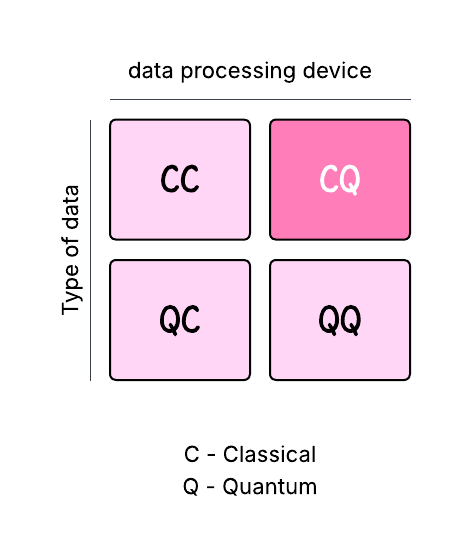<br>
Figure 1


####  **1.1 Classical Machine Learning vs. Quantum Machine Learning**

**Classical Machine Learning Pipeline**

1. Input data → numerical features (vectors, matrices)  
2. Classical model (e.g., neural network, SVM)  
3. Training via gradient-based optimization  
4. Output: predictions or classifications  



**Quantum Machine Learning Pipeline**

1. Classical data → **encoded into quantum states** (data embedding)  
2. **Parameterized quantum circuit (PQC)** processes data  
3. **Measurement** converts quantum states back to classical results  
4. Classical optimizer updates the quantum circuit parameters  

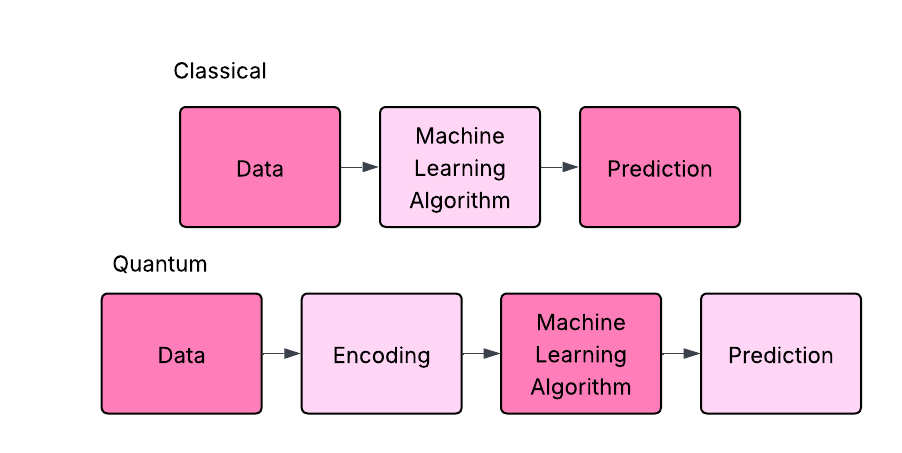

#### **1.2 Motivation & advantages of QML**

**1. What Quantum Computing Can Offer to Machine Learning**

-  **Speedups in computation** : Quantum algorithms (like HHL or Grover’s) could accelerate parts of ML workflows such as optimization, sampling, and linear algebra.
-  **Richer feature spaces** : Quantum states can represent exponentially large Hilbert spaces, enabling novel forms of data encoding and classification.
- **Quantum-inspired models** : Even without full quantum advantage, quantum concepts can inspire new classical algorithms and hybrid methods.
- **Hybrid quantum–classical learning** : Combining quantum circuits with classical optimizers can yield models tailored for today’s NISQ (Noisy Intermediate-Scale Quantum) devices.

**2. What Machine Learning Can Offer to Quantum Computing**

-  **Device calibration and noise mitigation** : ML can learn to control imperfect quantum hardware and adapt to noise in real time.
- **Optimization and parameter tuning** : Quantum circuit parameters can be optimized using classical ML techniques like gradient descent, reinforcement learning, or Bayesian optimization.
- **New perspectives on learning** : Machine learning raises fundamental questions about what it means for a *quantum system* to “learn” or “generalize”.
- **Driving commercial applications** : Linking quantum computing with ML’s multi-billion-dollar ecosystem may provide the “killer app” that pushes quantum computing toward real-world adoption.

#### **1.4 Quantum Circuits as models (QNN, VQC, QSVM)**

Quantum circuits can serve as **machine learning models** by using *trainable parameters* within quantum gates.  
These types of circuits are known as **Variational Quantum Circuits** or **Parameterized Quantum Circuits (PQCs)** and they form the foundation of many quantum machine learning algorithms.<br><br>

<p align="center">
  <img src="https://raw.githubusercontent.com/OlaTarig/Qiskit-Fall-Fest/6fa6e51da91c8c3eee36419d1f40bd1b5d923cd1/QML%20-%20Page%202.png"
       alt="Qiskit Fall Fest Banner"
       width="100%">
</p>

#####  **1.4.1 Quantum Circuits as models**

Any quantum machine learning model circuit consists of:
1. **Data encoding** — embedding classical input data into a quantum state.  
2. **Parameterized circuit (ansatz - variational circuit)** — quantum gates with tunable parameters (θ).  
3. **Measurement** — extracting information (expectation values) from the quantum state.
<br>

![Variational Circuit](https://raw.githubusercontent.com/OlaTarig/Qiskit-Fall-Fest/6fa6e51da91c8c3eee36419d1f40bd1b5d923cd1/QML%20-%20Page%203.png
)


##### **1.4.2 Making Predictions**

After training, the quantum circuit produces results that depend on the **primitive** used to run it.  
Different primitives extract different kinds of information from the circuit — which affects how we interpret predictions.


  **Using the `Sampler` Primitive**
- The circuit is executed multiple times to produce **bitstrings** (e.g., 000, 101, 111).  
- These bitstrings form a **sampling distribution**, representing measurement outcomes.  
- Predictions are derived from how often certain outcomes appear.  
  - For **classification** → outcomes like `0` and `1` can directly represent classes.  
  - For **multi-class tasks** → probabilities of each bitstring can be used as class likelihoods.

**Using the `Estimator` Primitive**
- Instead of raw bitstrings, the Estimator computes **expectation values** of observables (e.g., ⟨Z⟩).  
- These are real numbers between −1 and +1 that summarize the average measurement outcome.  
  - For **regression** → ⟨Z⟩ serves as a continuous prediction.  
  - For **classification** → thresholds like can map values to classes.


#####  **1.4.3 Optimization in QML**


1. Quantum computer executes the circuit → returns measurement results.  
2. calculates the **loss function**.  
3. Optimizer updates the parameters θ to minimize the loss.  

Common optimizers include:
- **COBYLA** (Constrained Optimization BY Linear Approximation)  
- **SPSA** (Simultaneous Perturbation Stochastic Approximation)  
- **Gradient Descent** and **Adam**

Challenges:
- **Noisy hardware** (NISQ limitation)  
- **Barren plateaus** — regions where gradients vanish, slowing learning.

#####  **1.4.4 Example Quantum Models**

| Model | Description |
|--------|--------------|
| **Variational Quantum Classifier (VQC)** | Classifies data using a variational circuit trained on labeled examples. |
| **Quantum Neural Network (QNN)** | General term for layered variational architectures inspired by neural networks. |
| **Quantum Support Vector Machine (QSVM)** | Uses quantum kernels to measure data similarity in high-dimensional Hilbert spaces. |
| **Quantum Generative Adversarial Network (QGAN)** | Mimics classical GANs; a generator and discriminator are implemented using quantum circuits.

## **2.0 Encoding Data into Qubits**


#### **2.1 Representing classical data in Qubits**

In Quantum Machine Learning (QML), **encoding classical data into quantum states** is one of the most critical steps.  
This process defines how classical information (numbers, vectors, or features) is transformed into a format that can be processed by a quantum circuit.

There are different **data encoding (data loading, state preparation)** strategies that offer different trade-offs between circuit depth, expressivity, and hardware efficiency.
Some of them are:
1. Basis Encoding
2. Amplitude Encoding
3. Angle Encoding
4. Phase Encoding
5. Dense Angle Encoding

In this notebook we will only explain phase encoding, but you can learn more about the other types in this [qiskit notebook](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding)

**Phase Encoding**

**Phase encoding** is a quantum data encoding method where classical input features are represented as **phase rotations** of qubits around the *Z-axis* of the Bloch sphere.

To start, each qubit is placed into a superposition using a **Hadamard gate**:

$$
H|0\rangle = |+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
$$

Then, each data feature $x_k$ is encoded into the qubit’s phase using a **Z-rotation** (or Phase) gate:

$$
R_Z(x_k)|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{ix_k}|1\rangle)
$$

This operation means that the value of $x_k$ directly affects the **relative phase** between the computational basis states $|0\rangle$ and $|1\rangle$.

For multiple features, each feature is applied to a separate qubit:

$$
|x\rangle = \bigotimes_{k=1}^{n} R_Z(x_k)H|0\rangle
$$

Phase encoding is **efficient**, it has a circuit depth of only 2 (one Hadamard layer and one rotation layer).

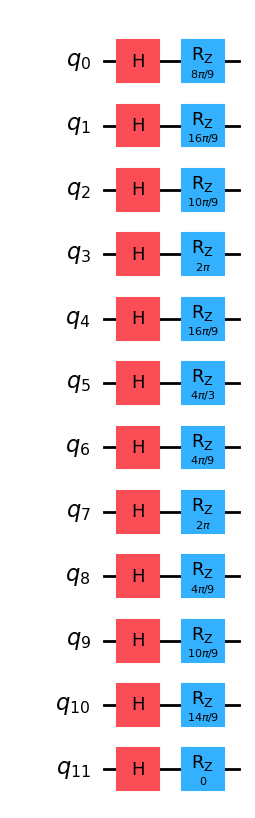

In [ ]:
#Phase Encoding Example
phase_data = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0]
qc = QuantumCircuit(len(phase_data))
for i in range(0, len(phase_data)):
    qc.h(i)
    qc.rz(phase_data[i] * 2 * pi / float(max(phase_data)), i)
qc.draw(output="mpl")


#### **2.2 Encoding with built-in Feature maps**


Quantum Feature Maps

As the name suggests, a quantum feature map $\phi(\mathbf{x})$ is a map from the classical feature vector $\mathbf{x}$ to the quantum state $|\Phi(\mathbf{x})\rangle\langle\Phi(\mathbf{x})|$. This is faciliated by applying the unitary operation $\mathcal{U}_{\Phi(\mathbf{x})}$ on the initial state $|0\rangle^{n}$ where _n_ is the number of qubits being used for encoding.

The feature maps currently available in Qiskit ([`PauliFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.PauliFeatureMap.html), [`ZZFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.ZFeatureMap.html) and [`ZFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.ZZFeatureMap.html)) are those introduced in [_Havlicek et al_.  Nature **567**, 209-212 (2019)](https://www.nature.com/articles/s41586-019-0980-2).

#### **2.3 PauliFeatureMap**

The `PauliFeatureMap` is defined as:

```python
PauliFeatureMap(feature_dimension=None, reps=2,
                entanglement='full', paulis=None,
                data_map_func=None, parameter_prefix='x',
                insert_barriers=False)
```
feature_dimension: Specifies the number of input features to encode which determines the number of qubits used.

entanglement: Defines how qubits are connected. Common options include linear and circular entanglement.

reps: Indicates how many times the feature map circuit is repeated, controlling the circuit depth.

paulis: Determines the set of Pauli operators (e.g., ['Z', 'ZZ']) used to build the feature map and define the type of data encoding.

This PauliFeatureMap describes the unitary operator of depth $d$:

$$ \mathcal{U}_{\Phi(\mathbf{x})}=\prod_d U_{\Phi(\mathbf{x})}H^{\otimes n},\ U_{\Phi(\mathbf{x})}=\exp\left(i\sum_{S\subseteq[n]}\phi_S(\mathbf{x})\prod_{k\in S} P_i\right), $$

which contains layers of Hadamard gates interleaved with entangling blocks, $U_{\Phi(\mathbf{x})}$, encoding the classical data as shown in circuit diagram below for $d=2$.

<div><img src="attachment:featuremap.png" width="1200" /></div>

Within the entangling blocks, $U_{\Phi(\mathbf{x})}$: $P_i \in \{ I, X, Y, Z \}$ denotes the Pauli matrices, the index $S$ describes connectivities between different qubits or datapoints: $S \in \{\binom{n}{k}\ combinations,\ k = 1,... n \}$, and by default the data mapping function $\phi_S(\mathbf{x})$ is

$\phi_S:\mathbf{x}\mapsto \Bigg\{\begin{array}{ll}x_i & \mbox{if}\ S=\{i\} \\(\pi-x_i)(\pi-x_j) & \mbox{if}\ S=\{i,j\}\end{array}$
    

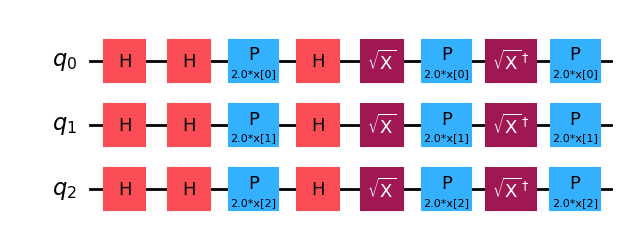

In [ ]:
# PauliFeatureMap
map_pauli = PauliFeatureMap(feature_dimension=3, reps=1,paulis = ['X','Y','Z'])#Try different values for the parameters to see how they change
map_pauli.decompose().draw('mpl')



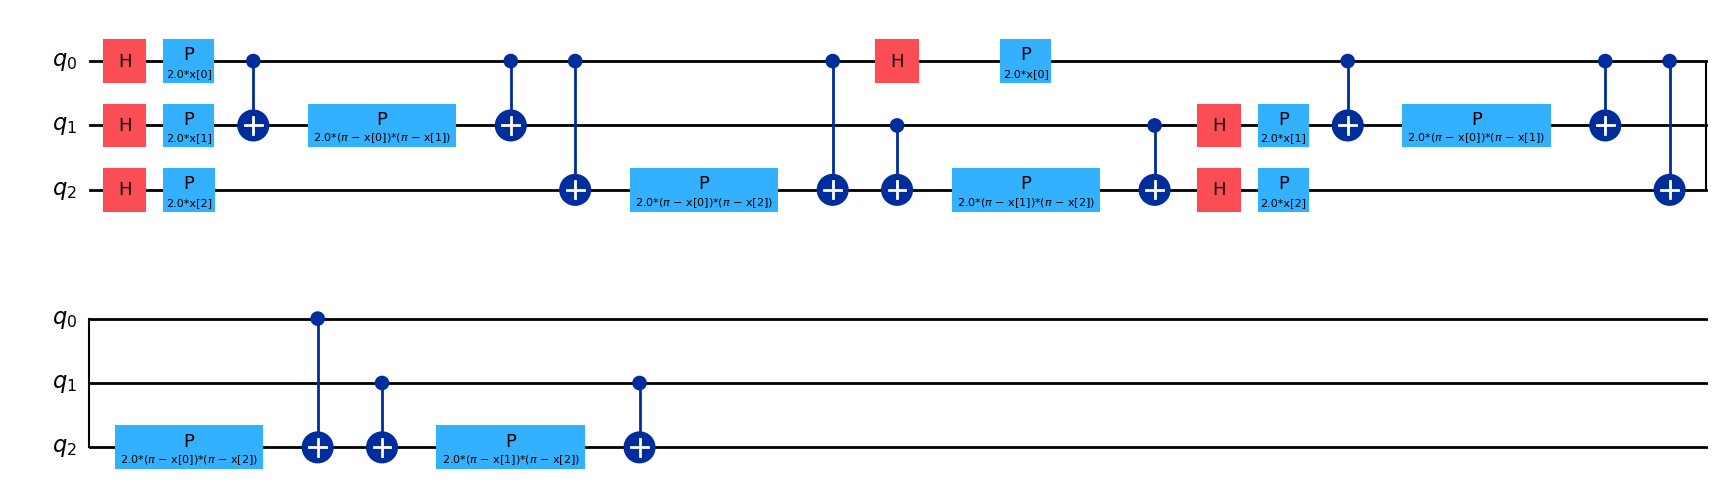

In [ ]:
#PauliFeatureMap with default paulis:
map_pauli = PauliFeatureMap(feature_dimension=3)
map_pauli.decompose().draw('mpl')

The default paulis operators used in the PauliFeatureMap are Z,ZZ which correspond to another well-known feature map which is the `ZZFeatureMap`, as shown in the cell below.

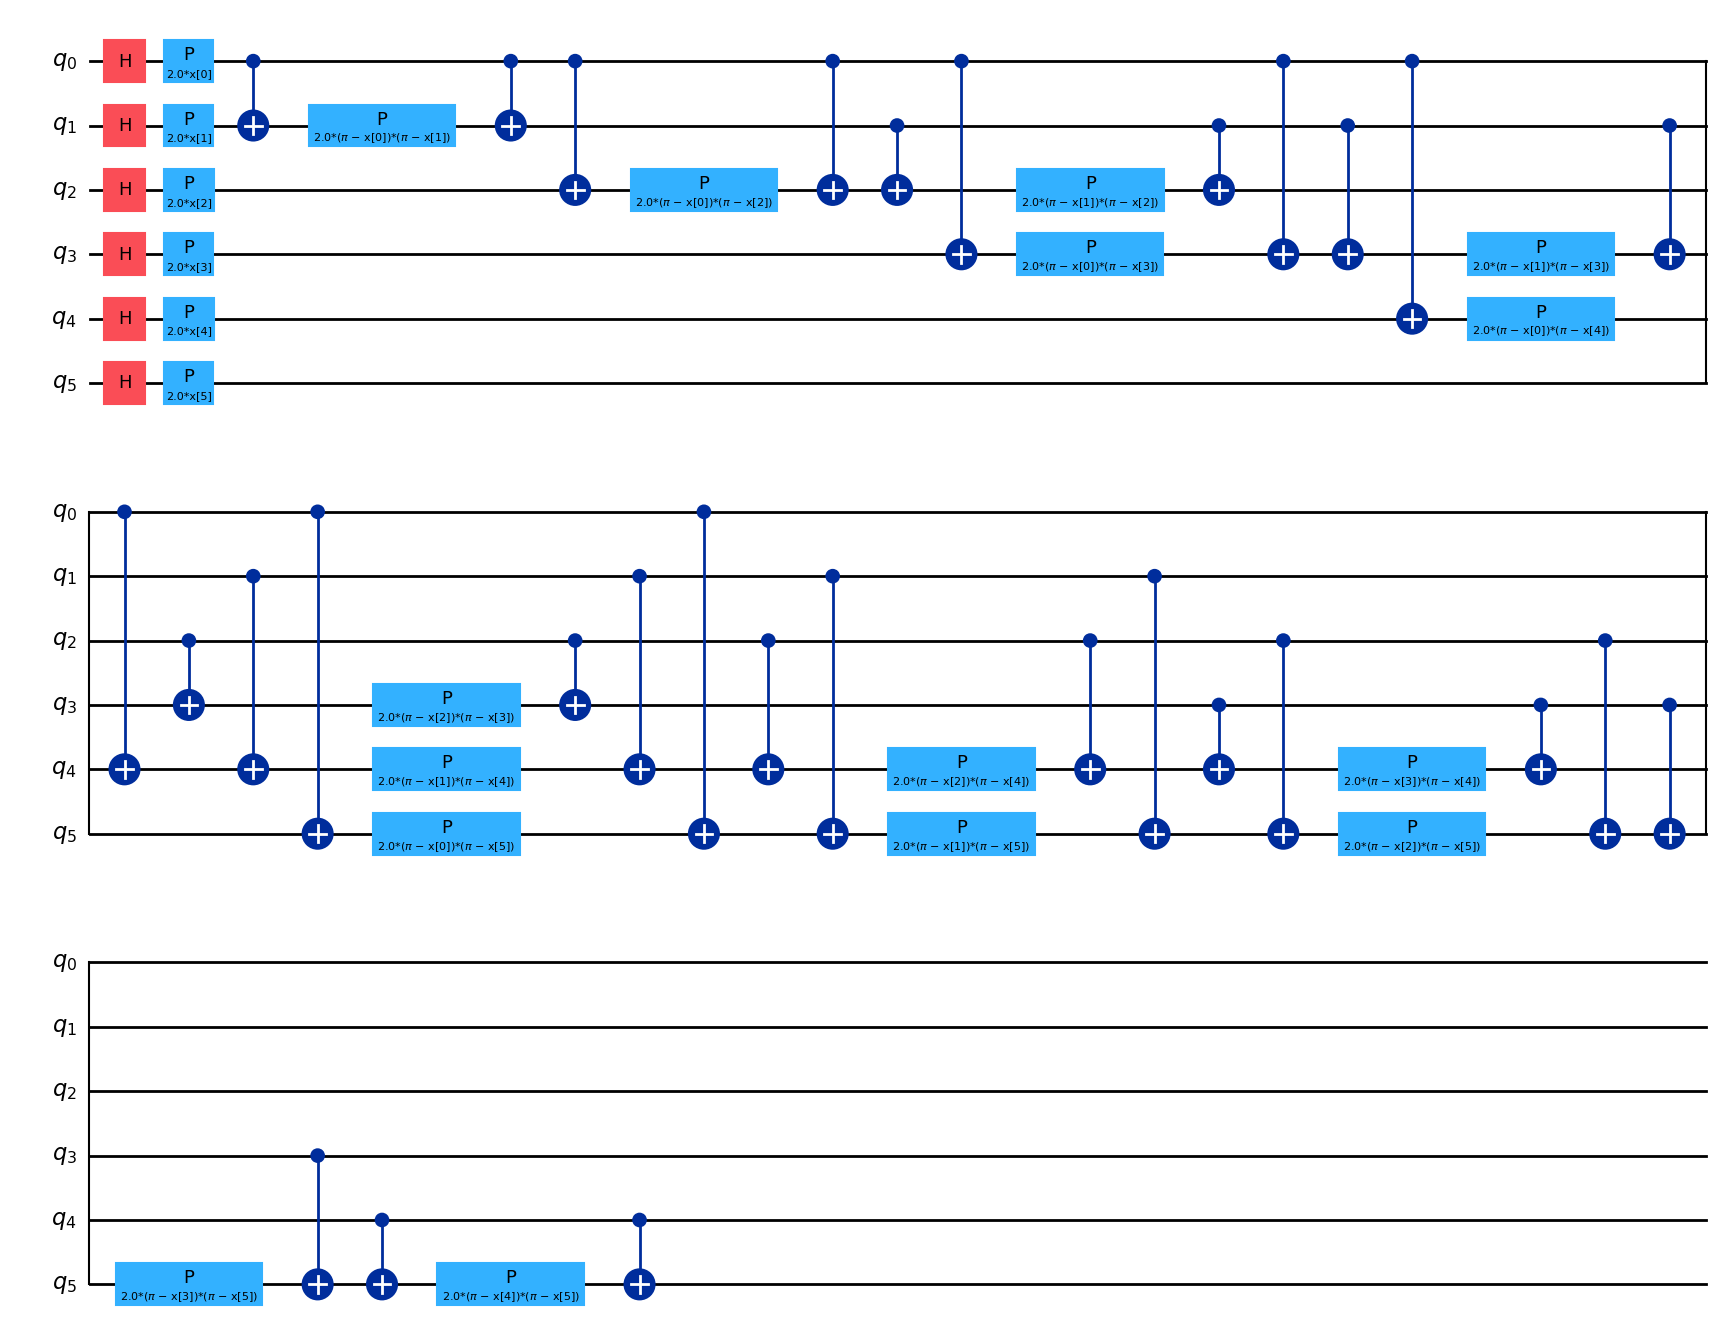

In [ ]:
# ZZFeatureMap
map_pauli = ZZFeatureMap(feature_dimension=6, reps=1)#Try different values for the parameters to see how they change
map_pauli.decompose().draw('mpl')

#### **How Does the Encoding Depth Affect the Results of the Model?**



Now you may ask yourself, how does the **depth of the encoding circuit** affect its behavior and performance?  

In general, **increasing the depth** of the feature map (or the number of encoding layers) gives the circuit **greater expressivity**.  
That means the quantum model can represent more complex relationships and capture deeper patterns hidden in the data.  
A deeper circuit can, in theory, map classical data into a higher-dimensional quantum space where the data becomes more separable.

However, **this isn’t always beneficial**.  
As the depth increases, the **computational cost** also rises, more gates, more parameters, and longer execution times.  
This can make the circuit harder to train, especially on real quantum hardware where noise and decoherence become significant issues.  

Moreover, **higher expressivity doesn’t automatically mean better performance**.  
Sometimes, the circuit becomes so flexible that it starts to **overfit** or gets trapped in **barren plateaus**, where gradients vanish, and optimization becomes extremely difficult.  
In fact, even though deeper quantum circuits are theoretically more powerful, they might not yield results that outperform well-tuned classical algorithms in practice.

In short, there’s a **trade-off**:  
- Shallow circuits are easier to train and more robust but might lack expressivity.  
- Deeper circuits are more expressive but come with higher computational demands and optimization challenges.


## **3.0 Quantum Nerual Network (QNN) Basics**

#### **3.1 QNN structure: Feature map + Variational circuit + Measurement**

![qnn](https://raw.githubusercontent.com/OlaTarig/Qiskit-Fall-Fest/8b7cc7c26cd4976f943f0fb018a2d3fb1b446943/QNN.jpg)

![NN](https://media.geeksforgeeks.org/wp-content/cdn-uploads/20230602113310/Neural-Networks-Architecture.png)

The qnn structure as we can see in the image above consists of:

**1. feature map**

**2. Parameterized Quantum Circuit (Ansatz Layers):**

After encoding, the quantum circuit applies a series of parameterized unitary transformations 𝑈(𝜃)


Each layer of the ansatz corresponds to a layer in a classical neural network.

Each ansatz is actually a series of rotation gates and entanglement
The trainable parameters 𝜃 are analogous to the weights and biases in classical models.

These parameters are optimized iteratively to minimize a chosen loss function, using either gradient-based methods (like the parameter-shift rule) or gradient-free optimizers (like COBYLA).

**3. Measurement (Output Layer):**

At the end of the circuit, we perform measurements on specific qubits.
The measured expectation values (e.g., ⟨𝑍⟩) serve as the output of the network.
Importantly, this measurement process introduces non-linearity into the model.

While classical neural networks rely on activation functions (such as ReLU or sigmoid) to introduce non-linearity,

In QNNs, the measurement of quantum observables naturally produces a non-linear relationship between the input data and the output probabilities.

#### **3.2 Parameters & Training Intuition**

The next step is tuning and optimizing these parameters ($\theta$), this step determines how well the QNN can learn to represent a desired function or make accurate predictions :
1. The **quantum circuit** computes the output (expectation value) for a given set of parameters.  
2. Then it evaluates the loss and updates the parameters using an optimization algorithm.  
Examples of loss functions are the MSE for regression problem or the cross entropy for classification problems
3. The updated parameters are sent back to the quantum circuit, and the process repeats until convergence.

There are different types of optimizers:

1. **Parameter-Shift Rule (Gradient-Based Optimization)**

The **parameter-shift rule** is the quantum analogue of computing gradients in classical backpropagation.

However, quantum circuits are not differentiable functions in the traditional sense, so we can’t simply apply the chain rule.  
Instead, we use a neat mathematical trick that allows us to compute the **exact gradient** using two additional evaluations of the circuit.

If the circuit’s output (expectation value) depends on a single parameter $\theta_i$, its derivative is:

$$
\frac{\partial f(\theta)}{\partial \theta_i} = \frac{f(\theta_i + \frac{\pi}{2}) - f(\theta_i - \frac{\pi}{2})}{2}
$$

**Intuition:**
- You run the same circuit **twice**:
  - once with the parameter shifted by $+\pi/2$,
  - and once by $-\pi/2$.
- The **difference between the two outputs**, scaled by $1/2$, gives the gradient.

This works because many quantum gates (like rotation gates) produce sinusoidal expectation values and the derivative of a sine function can be expressed as a simple shifted difference.

**Advantages**
- Provides **exact gradients** (not approximations).  
- Works well in simulation and on real quantum hardware for small circuits.  

**Drawbacks**
- Requires **multiple circuit evaluations per parameter**, which increases computational cost for large models.


2. **COBYLA Algorithm (Gradient-Free Optimization)**

While the parameter-shift rule is powerful, it can be inefficient on noisy or large quantum devices.  
In such cases, **gradient-free optimizers** like **COBYLA (Constrained Optimization BY Linear Approximations)** are very useful.

**How COBYLA works:**
- COBYLA doesn’t compute or approximate gradients directly.  
- Instead, it builds a **local linear model** of the loss function by evaluating it at several nearby points (forming a *simplex* in parameter space).  
- It then **moves the parameters** in the direction predicted to reduce the loss.  
- After each iteration, the simplex is updated to better approximate the shape of the loss landscape.

**Intuition:**
Think of standing on a hilly terrain with your eyes closed — you can’t see the slope (no gradients),  
but you can “feel” the height at a few nearby spots.  
COBYLA uses those samples to guess which direction is downhill and steps that way.

**Advantages**
- Works without gradients (useful on noisy quantum hardware).  
- Simple and robust for small QNNs.  

**Drawbacks**
- Can be slower to converge for high-dimensional parameter spaces.  
- May get stuck in local minima.

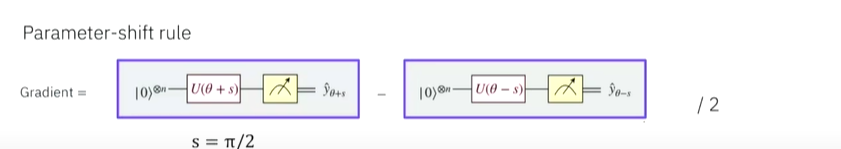

#### **3.3 Example: TwoLayerQNN Circuit**

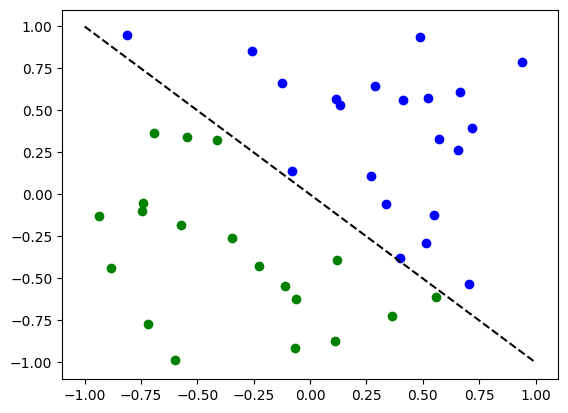

In [ ]:
# Generating and plotting data points
num_inputs = 2
num_samples = 40
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1
y01 = 1 * (np.sum(X, axis=1) >= 0)  # in { 0,  1}
y = 2 * y01 - 1  # in {-1, +1}
y_one_hot = np.zeros((num_samples, 2))
for i in range(num_samples):
    y_one_hot[i, y01[i]] = 1

for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

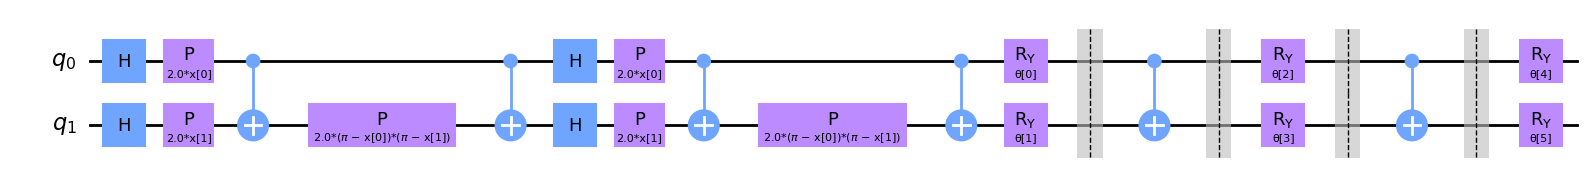

In [ ]:
# construct QNN with the QNNCircuit's default ZZFeatureMap feature map and RealAmplitudes ansatz.
qc = QNNCircuit(ansatz=RealAmplitudes(num_inputs, reps=2,insert_barriers = True))
qc.decompose().draw("mpl", style="clifford")

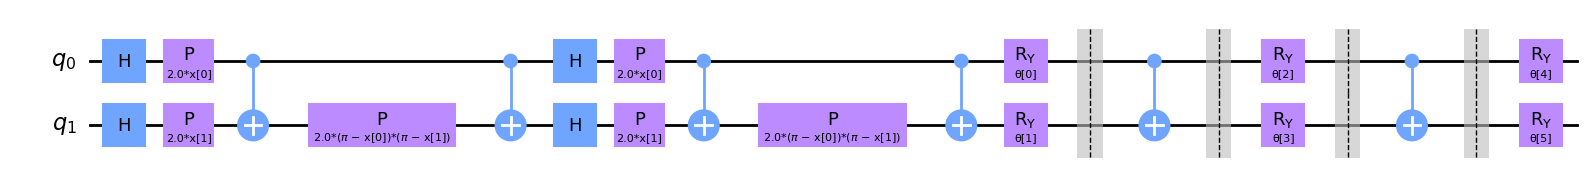

In [ ]:
qc.decompose().draw("mpl", style="clifford")

Using Estimator

In [ ]:
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
estimator_qnn = EstimatorQNN(circuit=qc, estimator=estimator)

In [ ]:
# QNN maps inputs to [-1, +1]
estimator_qnn.forward(X[0, :], algorithm_globals.random.random(estimator_qnn.num_weights))

array([[0.40087057]])

In [ ]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [ ]:
# construct neural network classifier
estimator_classifier = NeuralNetworkClassifier(
    estimator_qnn, optimizer=COBYLA(maxiter=60), callback=callback_graph
)

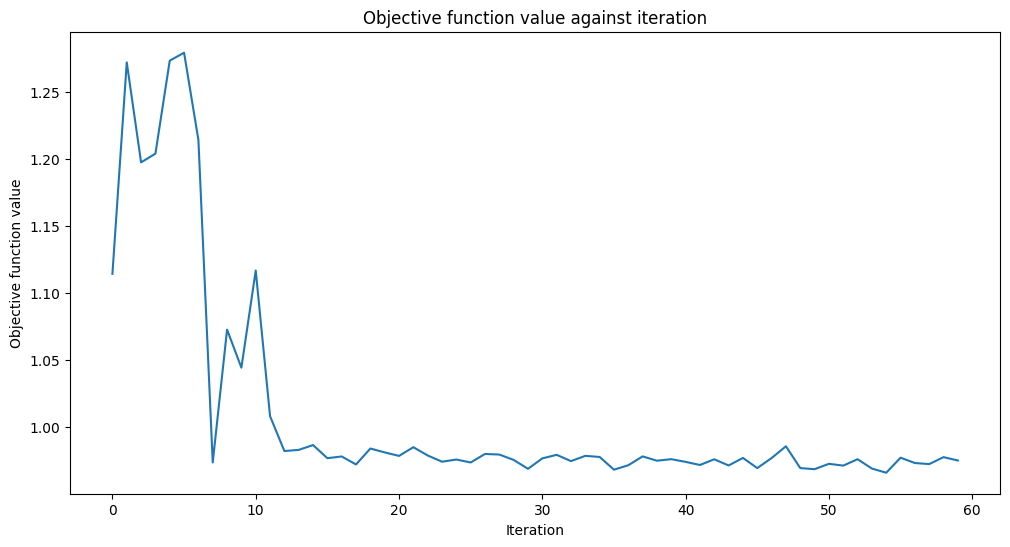

0.525

In [ ]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
estimator_classifier.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
estimator_classifier.score(X, y)

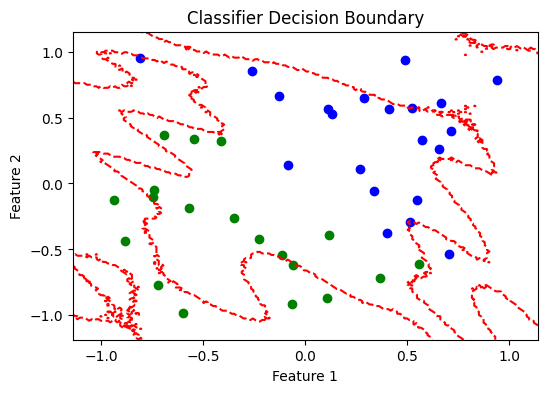

In [ ]:
#Visualizing the non linear decision boundary
# evaluate data points
y_predict = estimator_classifier.predict(X)

# plot results
for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")

# --- draw the decision boundary as a line ---
# create a mesh to predict across the input space
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# predict class for each point in the mesh
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = estimator_classifier.predict(grid_points)
Z = Z.reshape(xx.shape)

# plot decision boundary line (where class changes)
plt.contour(xx, yy, Z, levels=[0.5], colors="r", linestyles="--")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classifier Decision Boundary")
plt.show()


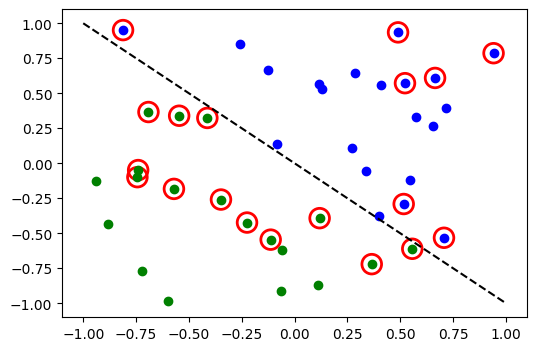

In [ ]:
# evaluate data points
y_predict = estimator_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

In [ ]:
estimator_classifier.weights

array([ 0.0512954 ,  0.67399266,  1.41020388, -0.4989243 , -0.0809453 ,
       -0.47565146])

Using Sampler

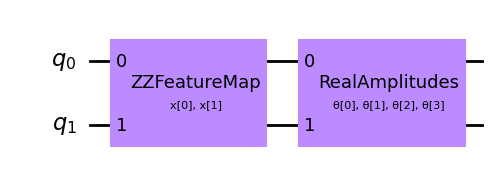

In [ ]:
# construct a quantum circuit from the default ZZFeatureMap feature map and a customized RealAmplitudes ansatz
qc = QNNCircuit(ansatz=RealAmplitudes(num_inputs, reps=1))
qc.draw("mpl", style="clifford")

In [ ]:
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2


output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping.

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
# construct QNN
sampler_qnn = SamplerQNN(
    circuit=qc,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler,
)

In [ ]:
# construct classifier
sampler_classifier = NeuralNetworkClassifier(
    neural_network=sampler_qnn, optimizer=COBYLA(maxiter=30), callback=callback_graph
)

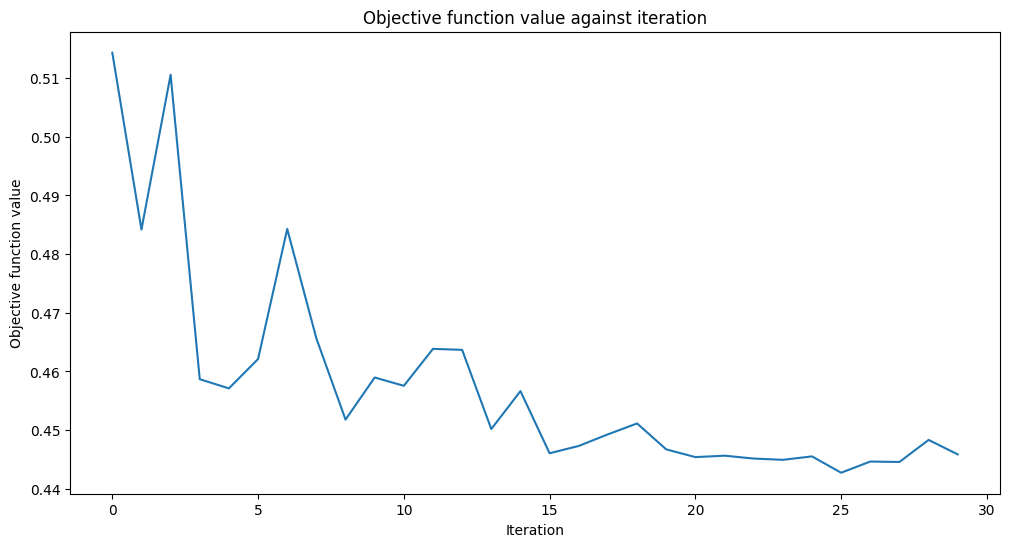

0.575

In [ ]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
sampler_classifier.fit(X, y01)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
sampler_classifier.score(X, y01)

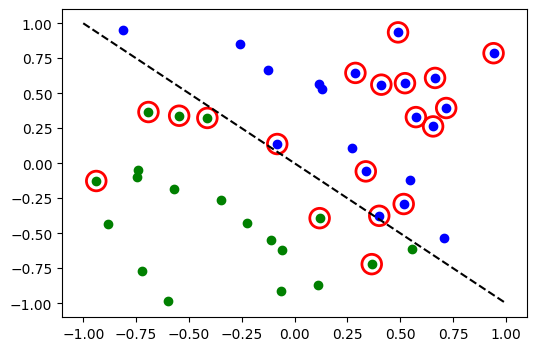

In [ ]:
# evaluate data points
y_predict = sampler_classifier.predict(X)

# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

In [ ]:
sampler_classifier.weights

array([1.24945205, 2.06996494, 1.40804073, 2.15740754])

## **4.0 Variational Classifier (VQC) – Small Demo**
A **Variational Quantum Classifier (VQC)** has the same structure as a Quantum Neural Network (QNN). However, a **VQC** is specifically designed for **classification**. It uses the output of the quantum circuit to assign **class labels** to the input data.  



#### **4.1 Load dataset**


Iris Dataset

The Iris dataset is a classic dataset in machine learning and statistics, introduced by Ronald Fisher in 1936. It consists of 150 samples of iris flowers from three species: Iris setosa, Iris versicolor, and Iris virginica.

Each sample has four features measured in centimeters:

Sepal length

Sepal width

Petal length

Petal width

The goal is typically classification: predicting the species of an iris flower based on these four measurements. The dataset is small, clean, and well-balanced, making it ideal for testing and demonstrating machine learning algorithms.

In [ ]:
from sklearn.datasets import load_iris

iris_data = load_iris()

In [ ]:
features = iris_data.data
labels = iris_data.target

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = MinMaxScaler().fit_transform(features)

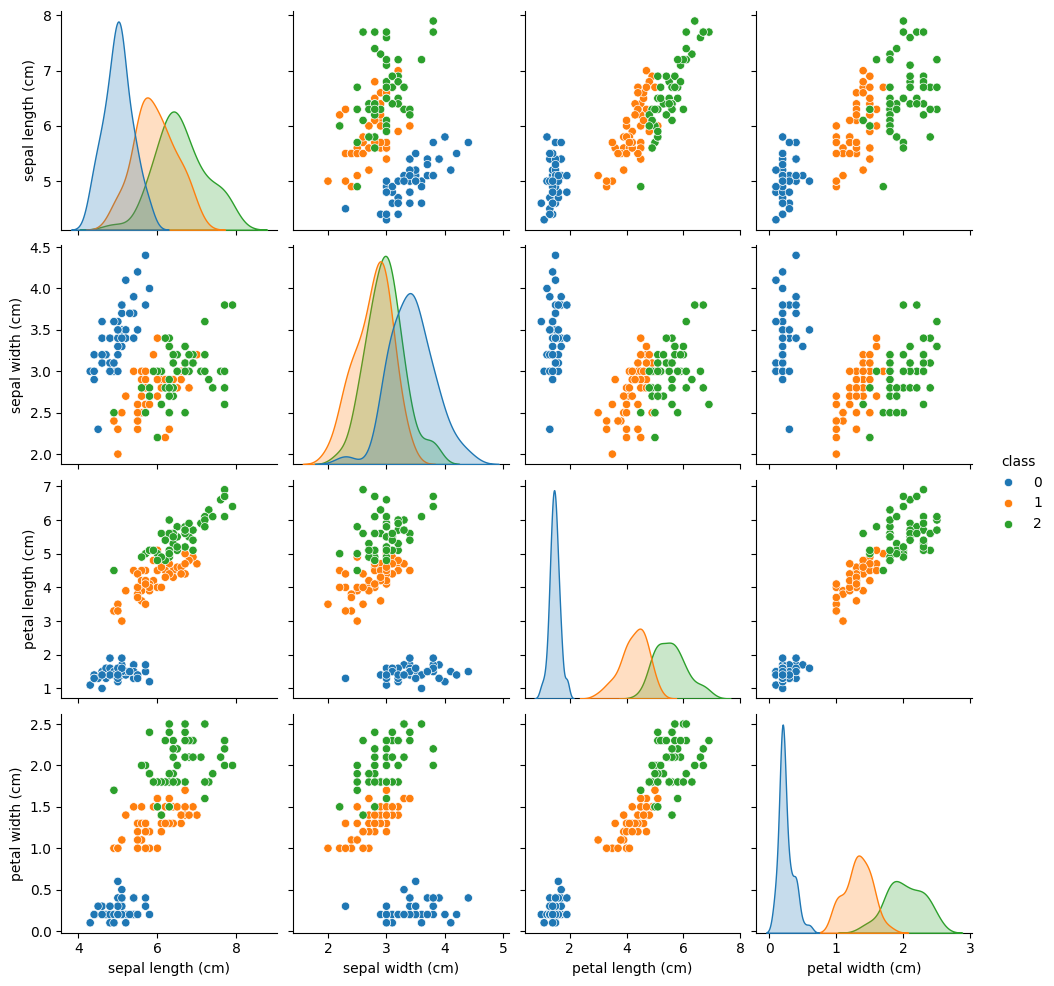

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["class"] = pd.Series(iris_data.target)

sns.pairplot(df, hue="class", palette="tab10")

In [ ]:
#Splitting training and test data

algorithm_globals.random_seed = 123
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, random_state=algorithm_globals.random_seed
)

#### **4.2 Create VQC instance with optimizer**


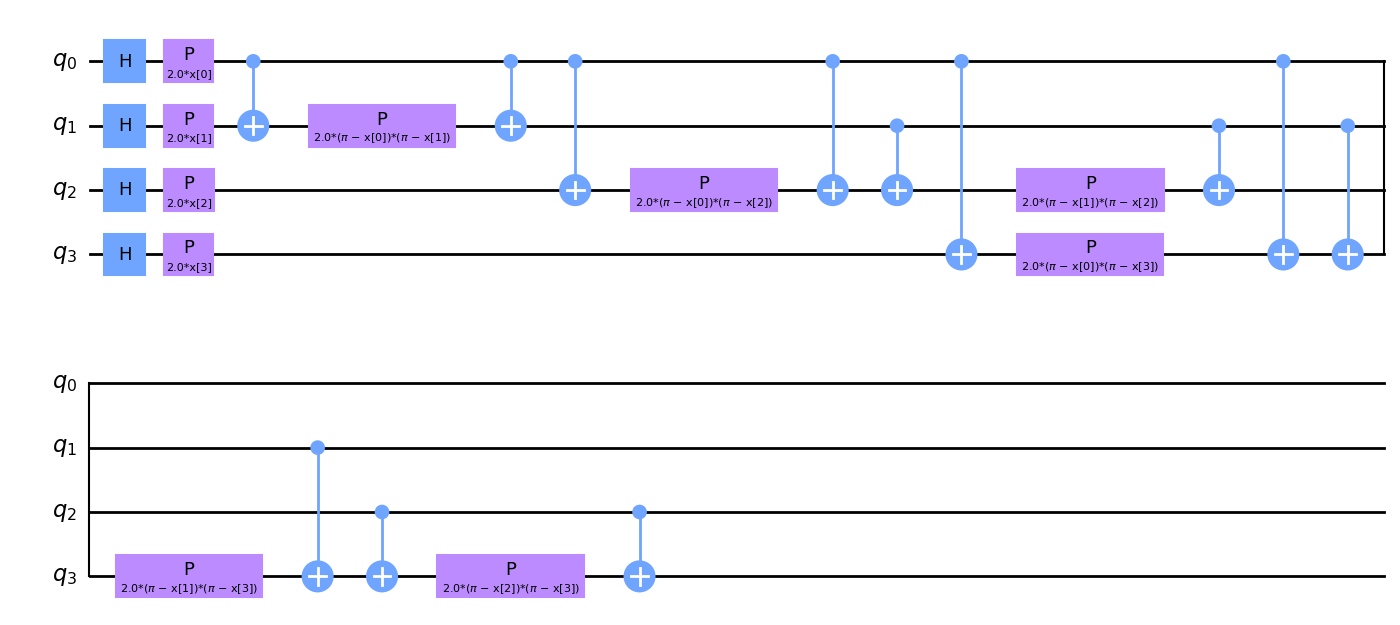

In [ ]:
#Choosing a Feature map for the optimization
num_features = features.shape[1]

feature_map = PauliFeatureMap(feature_dimension=num_features, reps=1)
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)

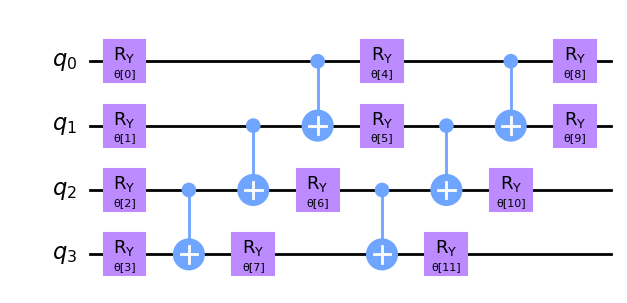

In [ ]:
#Choosing a variational circuit (ansatz)
ansatz = RealAmplitudes(num_qubits=num_features, reps=2)
ansatz.decompose().draw(output="mpl", style="clifford", fold=20)

In [ ]:
from qiskit_machine_learning.optimizers import COBYLA

optimizer = COBYLA(maxiter=100)

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

In [ ]:
from matplotlib import pyplot as plt
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)


def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [ ]:
import time
from qiskit_machine_learning.algorithms.classifiers import VQC
#vqc instance
vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)


#### **4.3 Train VQC**


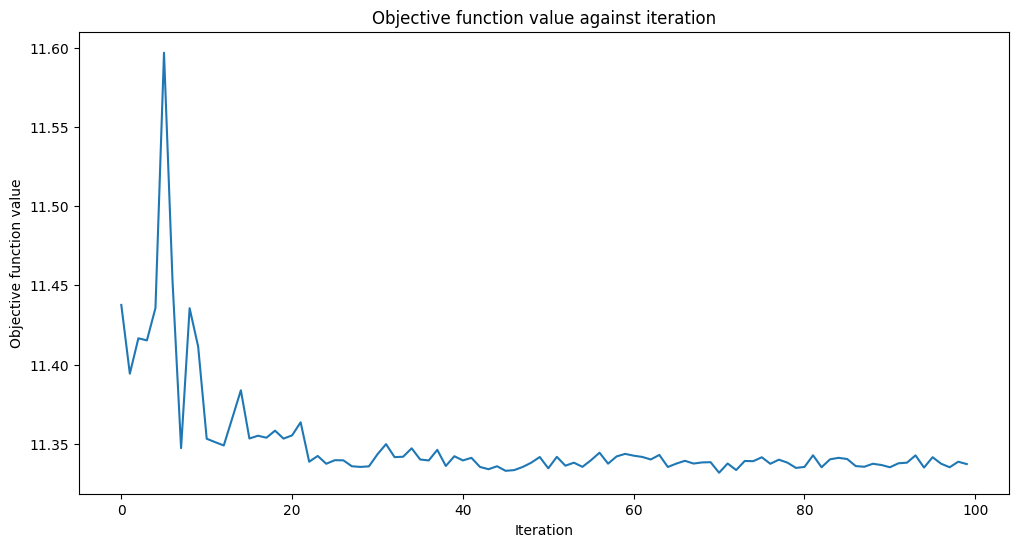

Training time: 157 seconds


In [ ]:

# clear objective value history
objective_func_vals = []

start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

#### **4.4 Predict test labels & display results**



In [ ]:
train_score_q4 = vqc.score(train_features, train_labels)
test_score_q4 = vqc.score(test_features, test_labels)

print(f"Quantum VQC on the training dataset: {train_score_q4:.2f}")
print(f"Quantum VQC on the test dataset:     {test_score_q4:.2f}")

NameError: name 'vqc' is not defined

#### **4.5 Compare with a classical model**


In [ ]:
from sklearn.svm import SVC

svc = SVC()
_ = svc.fit(train_features, train_labels)  # suppress printing the return value

In [ ]:
train_score_c4 = svc.score(train_features, train_labels)
test_score_c4 = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score_c4:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c4:.2f}")

Classical SVC on the training dataset: 0.99
Classical SVC on the test dataset:     0.97


In [ ]:
print(f"Model                           | Test Score | Train Score")
print(f"SVC, 4 features                 | {train_score_c4:10.2f} | {test_score_c4:10.2f}")
print(f"VQC, 4 features, RealAmplitudes | {train_score_q4:10.2f} | {test_score_q4:10.2f}")

Model                           | Test Score | Train Score
SVC, 4 features                 |       0.99 |       0.97
VQC, 4 features, RealAmplitudes |       0.57 |       0.53


From the results, it’s clear that the **classical SVC (Support Vector Classifier) outperforms the quantum classifier** on this dataset. This is expected for small, clean datasets like Iris, but Why ?:  

1. **Dataset size and simplicity**  
   *  Classical algorithms like SVC excel at finding **linear or simple non-linear boundaries** in small datasets.  
   * The Iris dataset has only **150 samples and 4 features**, so classical models already perform near-perfectly.  

2. **Limitations of current quantum models**  
   - Variational Quantum Classifiers (VQCs) and QNNs have **few qubits and shallow circuits** on simulators or NISQ devices.  
   - Training is often **challenging due to barren plateaus** where gradients vanish, and optimization can get stuck.  
   - On real quantum hardware, **noise and decoherence** further reduce performance.  

3. **Computation overhead**  
   * Quantum circuits require more computational resources to simulate.  
   * For small datasets, this overhead outweighs any potential benefit, so classical methods are faster and more accurate.  


So, you may ask yourself, When does actually quantum models provide real value ?

Quantum models can outperform classical ones in certain scenarios:

- **High-dimensional datasets**  
  - Quantum circuits can encode classical data into a **high-dimensional Hilbert space** efficiently, where classical methods struggle.  

- **Problems with inherently quantum structure**  
  - Tasks in **quantum chemistry, materials science, or quantum physics** may benefit from quantum models that naturally capture quantum correlations.  

- **Complex non-linear relationships**  
  - Some highly non-linear mappings are **difficult for classical models** but easier for QNNs with entanglement and sufficient depth.  

- **Hard-to-estimate classical kernels**  
  - Quantum classifiers can implement **quantum kernels** that are **computationally expensive or impossible to calculate classically**.  
  - In such cases, a quantum classifier can provide **better generalization** by implicitly working in a feature space that classical SVCs cannot efficiently access.  

- **Future potential with more qubits and better hardware**  
  - As quantum hardware improves, deeper and less noisy circuits will allow quantum models to **surpass classical performance** for suitable problems.  
And actually finding suitable problems in whicha really quantum models outperform the classical ones, is an open research question.


> Until now, Most of the proven advantages of qml over classical alogoritms comes from **research papers and theoretical analyses** that suggest quantum circuits could, in principle, provide **speedups or better expressivity** for certain problems.   However, on current **near-term devices** and with **small datasets**, classical algorithms**still outperform quantum models** in terms of accuracy, stability, and training speed.  

>In other words, QML is **promising and full of potential**

**Challenge**:

By now, you have learned the steps of building a quantum model, and the main element in it is the **ansatz**. We also saw that it is basically a mix of **rotations and entanglements**.  

Now, try **ansatz** and use it to build a classifier following the steps we did before. Then, check and tell us **what accuracy score did you get**.  

**Hint:** use [`ParameterVector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.ParameterVector).


## **6.0 Wrap-up**

#### **6.1 Recap of QML Pipeline**
In this notebook, we explored the steps of building a quantum machine learning model:
1. **Data encoding**  
2. **Variational circuit (ansatz)**
3. **Measurement**
4. **Training**   
5. **Evaluation**

#### **6.2 Connection with Previous Algorithms**

###### **6.2.1 Connection with Shor's Algorithm**
Shor’s algorithm is a quantum algorithm for **integer factorization**. While it is not a machine learning algorithm, it demonstrates how **quantum circuits can exploit superposition and interference** to solve problems that are classically hard. Similarly, QML models use quantum circuits to encode and process data in **high-dimensional Hilbert spaces**, potentially enabling new types of learning.

###### **6.2.2 Connection with QAOA**
The **Quantum Approximate Optimization Algorithm (QAOA)** is a variational algorithm for solving combinatorial optimization problems. Like VQCs and QNNs, QAOA uses a **parameterized quantum circuit** (ansatz) and a classical optimizer to minimize a cost function. This shows that **variational circuits are a common building block** across different quantum algorithms, from optimization to machine learning.

#### **6.3 Advanced QML Algorithms**
Beyond basic VQCs, there are more advanced quantum machine learning techniques, such as:
- **Quantum Kernel Methods** — exploiting quantum states to compute kernels that are hard to evaluate classically.  
- **Quantum qGANs** — hybrid quantum-classical models using quantum circuits to learn the underlying probability distribution given training data.
- **Quantum Boltzmann Machines (QBM)** — quantum versions of classical Boltzmann machines that use quantum states to model complex probability distributions and correlations that are hard to capture classically.

#### **6.4 References to some articles about QML Advantages**
These are links to some papers and articles about the proven advantages of quantum over classical, you can read them later and I hope you enjoy them:

- Yamasaki, H., Isogai, N., & Murao, M. (2023). *Advantage of Quantum Machine Learning from General Computational Advantages*. arXiv:2312.03057.  
  https://arxiv.org/abs/2312.03057  
  This paper constructs a new class of supervised learning tasks (on classical data) for which quantum algorithms can **provably outperform any classical polynomial-time algorithm**.

- IBM Research Blog: “Quantum kernels can solve machine learning problems that are hard for all classical methods.”  
  https://research.ibm.com/blog/quantum-kernels  
  The authors describe a quantum kernel method for a specially constructed classification task, proving an **exponential speedup** for that task under standard hardness assumptions.

- IBM Quantum Blog: “The power of quantum neural networks.”  
  https://www.ibm.com/quantum/blog/quantum-neural-network-power  
  This article discusses how quantum neural networks may achieve **higher model capacity** than classical networks, using the concept of *effective dimension*, and shows examples where QNNs train faster or generalize better in some scenarios.


![Thank u](https://i.imgflip.com/3rtjwb.jpg)

### **References**

[1] Qiskit Community, *Qiskit Machine Learning Tutorials*. [Online]. Available: https://qiskit-community.github.io/qiskit-machine-learning/tutorials  
[2] Qiskit Textbook Team, *Quantum Machine Learning Course (GitHub)*. [Online]. Available: https://github.com/Qiskit/textbook/tree/main/notebooks/quantum-machine-learning  
[3] IBM Quantum, *Qiskit Global Summer School 2021 Labs: Quantum Machine Learning*. [Online]. Available: https://github.com/kamalini-hub/Qiskit-Global-Summer-School-2021/tree/main  
[4] YouTube, *Qiskit Global Summer School 2021 YouTube Playlist*. [Online]. Available: https://youtube.com/playlist?list=PLOFEBzvs-VvqJwybFxkTiDzhf5E11p8BI&si=O7mDCuJwugT4cS5l  

[5] IBM Quantum Learning, *Data Encoding – Quantum Machine Learning*. [Online]. Available: https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding  


[6] M. Schuld and F. Petruccione, *Supervised Learning with Quantum Computers*. Cham, Switzerland: Springer, 2018.



##### **The Notebook made by QFF KSU 2025 Organizing Team:**
Hassan Alhusayni - Co-organizer.

Mohamedelfaith Seedahmed -Lead Organizer.

Ola Mahjoub - Co-organizer.